# CCO06: Change cell type number of clusters and conduct scVelo analysis

In [3]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import glob
import scipy

In [1]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06

In [6]:
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO05"
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO06"

## 1. Relabel cell type according to Jun's label

In [10]:
%%bash

mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/cell_type_labelled

mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/dotplots

In [11]:
%%bash
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__ALL-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/ALL.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__BHO-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/VHO.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__BVO-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/VO.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__CM3B-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/VCO.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__CM3O-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/CA.h5ad
ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata/SC160__HO-JW-052224.h5ad /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/leiden_clustered/HO.h5ad

/tmp/ipykernel_1226053/195061385.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pat.obs['leiden'][0] = j
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/tmp/ipykernel_1226053/195061385.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pat.obs['leiden'][0] = j
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/annd

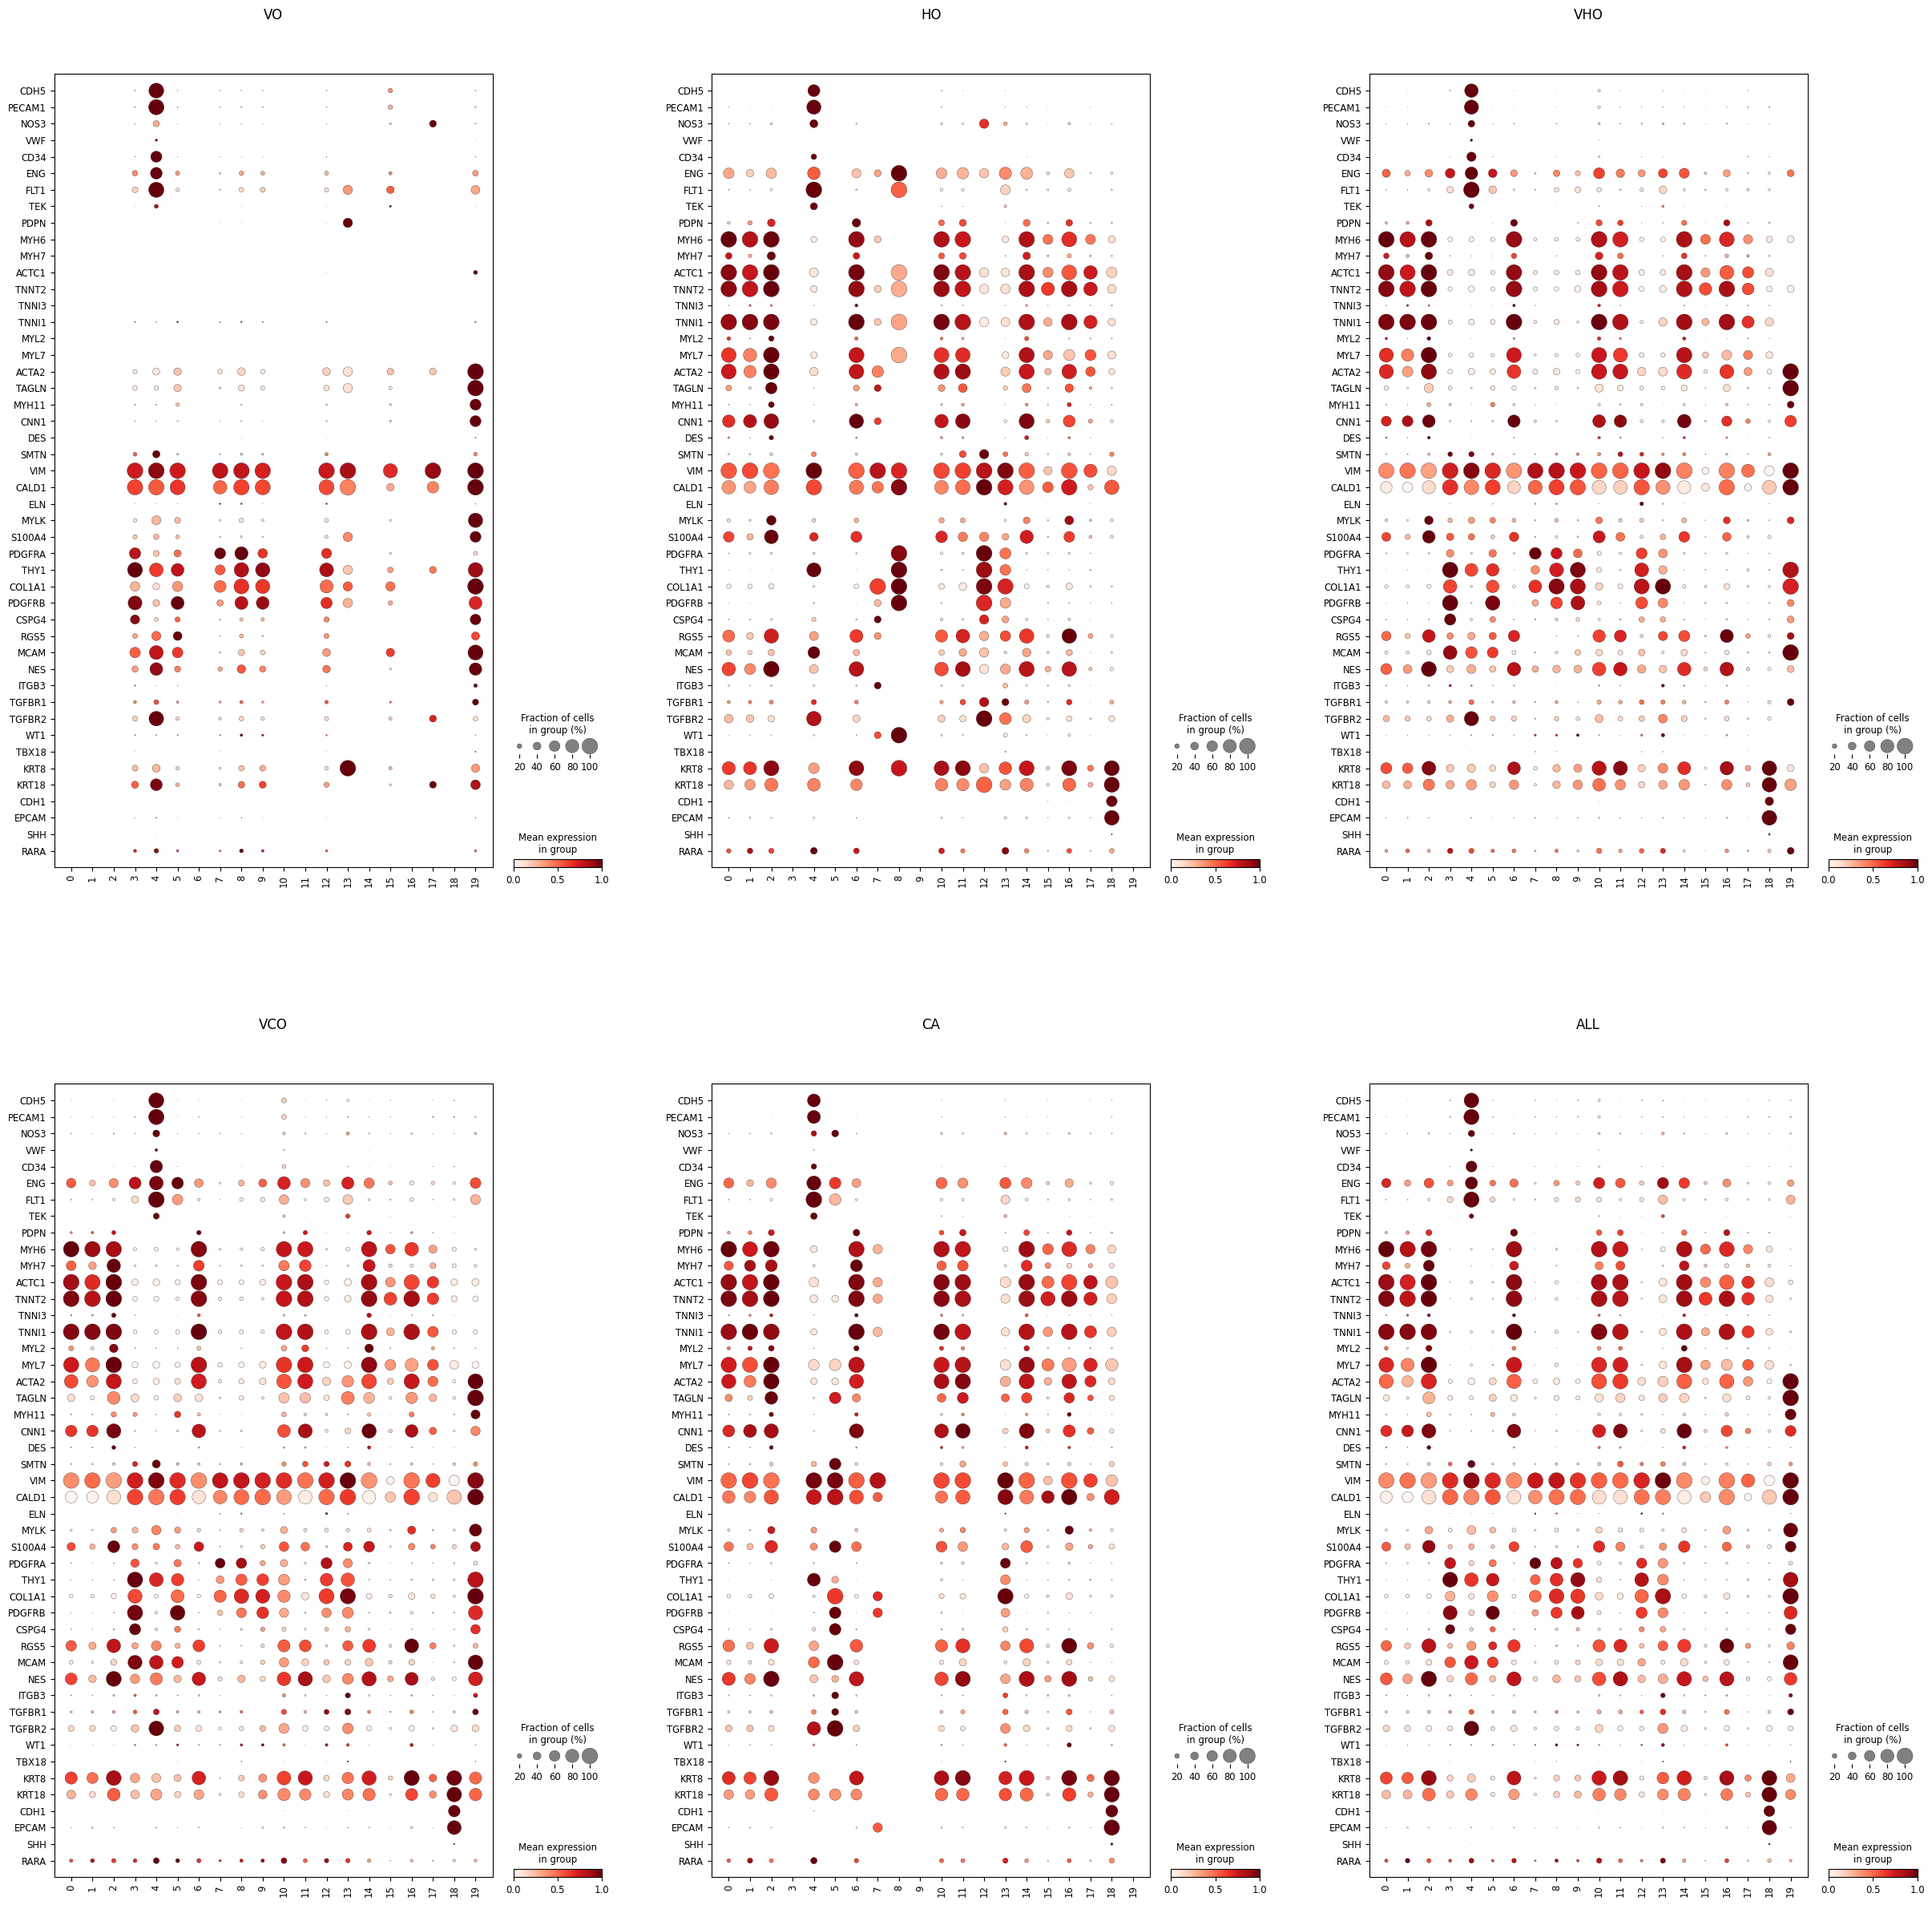

In [15]:
marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
               'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
               'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
               'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
               'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/leiden_clustered/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).any():
            continue
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    sc.pl.dotplot(adata, marker_dict, groupby="leiden", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/dotplot_leiden.png')
plt.show()

In [5]:
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

celltypes_dict = {
    '0': 'CM', 
    '1': 'CM',
    '2': 'CM',
    '3': 'PR',
    '4': 'EN',
    '5': 'PR',
    '6': 'CM',
    '7': 'FB',
    '8': 'FB',
    '9': 'FB',
    '10': 'CM',
    '11': 'CM',
    '12': 'FB',
    '13': 'SM',
    '14': 'CM',
    '15': 'CME',
    '16': 'CM',
    '17': 'CME',
    '18': 'EP',
    '19': 'SM',
}

In [6]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/uamps

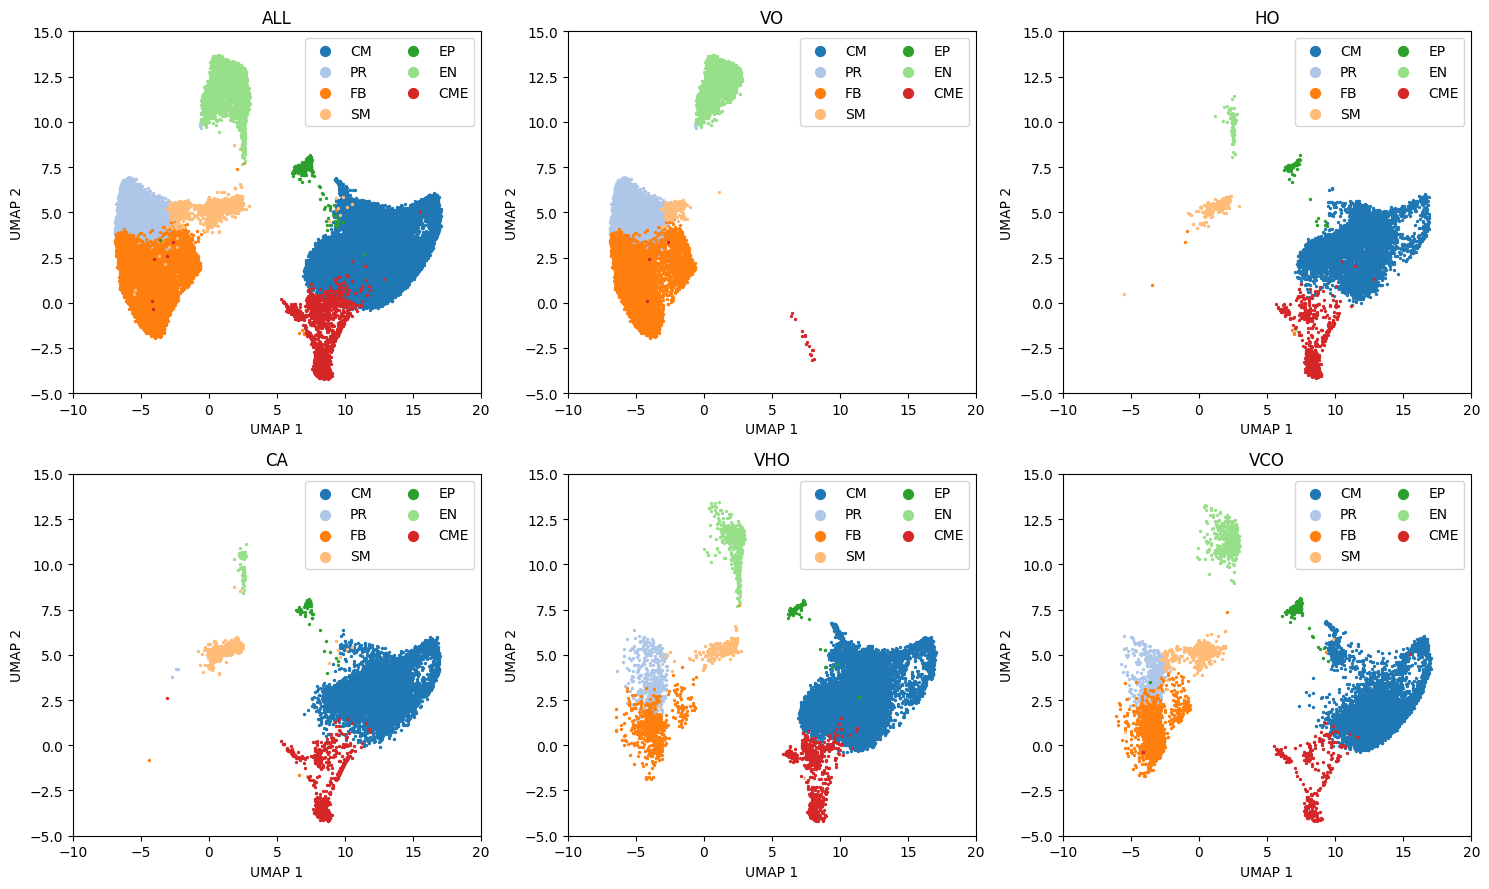

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

cell_types = ['CM','PR','FB','SM','EP','EN','CME']
cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors

batch_mapper = dict(zip(samples_old, samples))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/leiden_clustered/{sample}.h5ad')
    adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict)
    
    adata.obs['batch'] = adata.obs['batch'].astype('str')
    adata.obs['batch'] = adata.obs['batch'].map(batch_mapper)
    adata.obs['batch'] = adata.obs['batch'].astype('category')
    
    adata.write(f'{WORK_DIR}/adata/cell_type_labelled/{sample}.h5ad')
    
    for j, ct in enumerate(cell_types):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=ct, 
            color=colors[j], s=2)
        
    axs[i].legend(loc='upper right', markerscale=5, ncol=2)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-10, 20])
    axs[i].set_ylim([-5, 15])
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/cell_type_labelled.png')
plt.show()

## 2. Split cell types and recluster

In [59]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/cell_type_split
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/cell_type_subclustered

In [4]:
cell_types = ['CM','PR','FB','SM','EP','EN','CME']
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

In [8]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
for ct in cell_types:
    adata = adata_all[adata_all.obs['cell_type'] == ct]
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")

### 2.1 Cardiomyocytes - aim for 4 clusters

In [33]:
ct = "CM"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.3)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_1044410/3310301907.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCAAGAAGGGAT-1-0    2
AAACCCAAGTCAGGGT-1-0    1
AAACCCACATCCAACA-1-0    1
AAACCCAGTAGATGTA-1-0    1
AAACCCAGTAGTACGG-1-0    1
                       ..
TTTGTTGAGACTGGGT-1-4    1
TTTGTTGAGATTGACA-1-4    3
TTTGTTGAGGGTACGT-1-4    3
TTTGTTGTCATGCCGG-1-4    5
TTTGTTGTCGTTGCCT-1-4    6
Name: leiden, Length: 25615, dtype: category
Categories (8, object): ['0', '1', '2', '3', '4', '5', '6', '7']

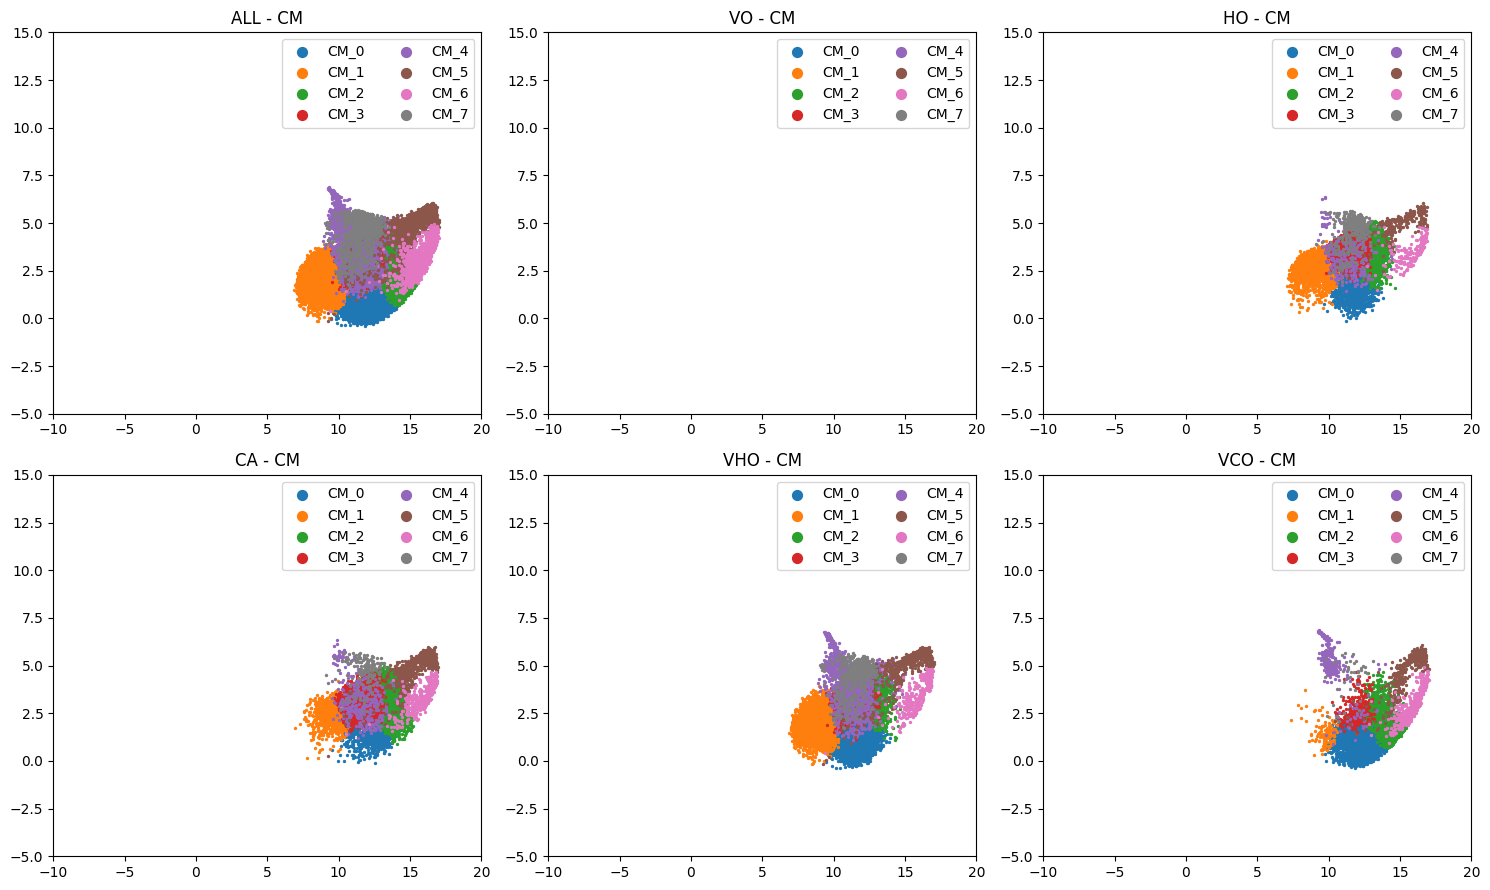

In [34]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=2)
    
    ax.set_xlim([-10, 20])
    ax.set_ylim([-5, 15])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.png')
plt.show()

In [35]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

### 2.2 Fibroblast

In [36]:
ct = "FB"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
# sc.tl.leiden(adata, resolution=0.1)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_1044410/2447842915.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCATCATTGCGA-1-0    1
AAAGGATAGCGCCTAC-1-0    1
AAAGGGCTCTCGGTAA-1-0    0
AAAGGTAGTCCACAGC-1-0    3
AAAGTGATCTCATAGG-1-0    2
                       ..
CAGGGCTCAAGCACAG-1-4    1
CCTCATGGTCTGTGGC-1-4    0
CGCATAATCATTGCCC-1-4    3
CTCCTCCAGTCCTGTA-1-4    0
TCTACATAGGTTATAG-1-4    0
Name: leiden, Length: 9742, dtype: category
Categories (4, object): ['0', '1', '2', '3']

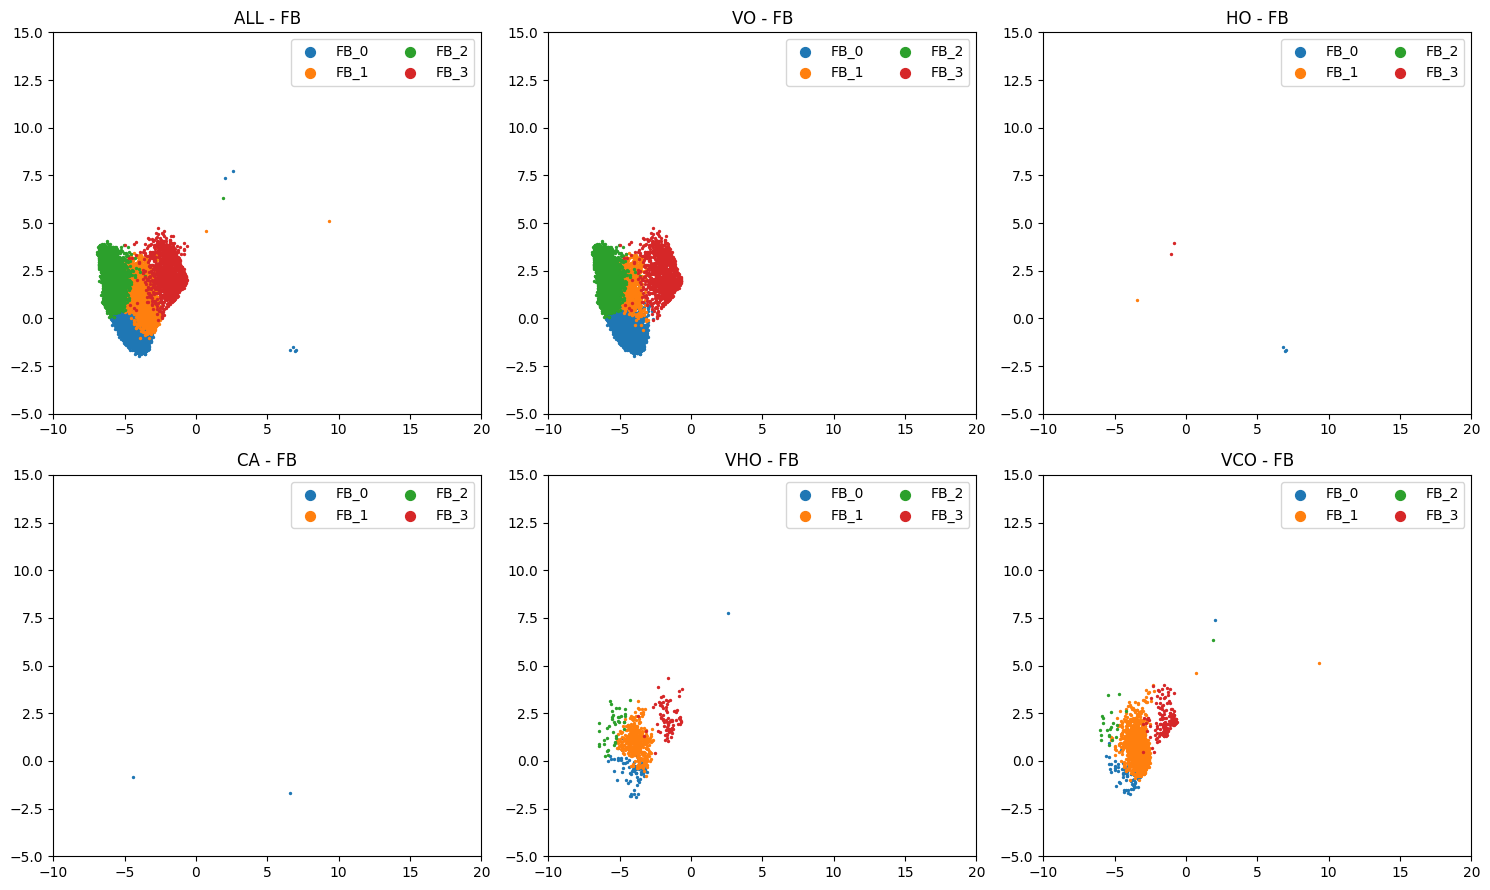

In [37]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=2)
    
    ax.set_xlim([-10, 20])
    ax.set_ylim([-5, 15])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.png')
plt.show()

In [38]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

### 2.3 endothelial cells

In [39]:
ct = "EN"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.5)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_1044410/1151569868.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCACATCCTTGC-1-0    2
AAAGAACAGGGCAATC-1-0    2
AAAGGATGTCAAGCGA-1-0    2
AAAGGGCCAGCGTATT-1-0    0
AAATGGAAGCTGCCAC-1-0    1
                       ..
TTAGGCAGTGTGTCGC-1-4    2
TTCGCTGCAAGTGGGT-1-4    2
TTTACTGGTAGACACG-1-4    2
TTTCAGTAGCGCTGAA-1-4    2
TTTGATCAGCGCACAA-1-4    2
Name: leiden, Length: 4175, dtype: category
Categories (4, object): ['0', '1', '2', '3']

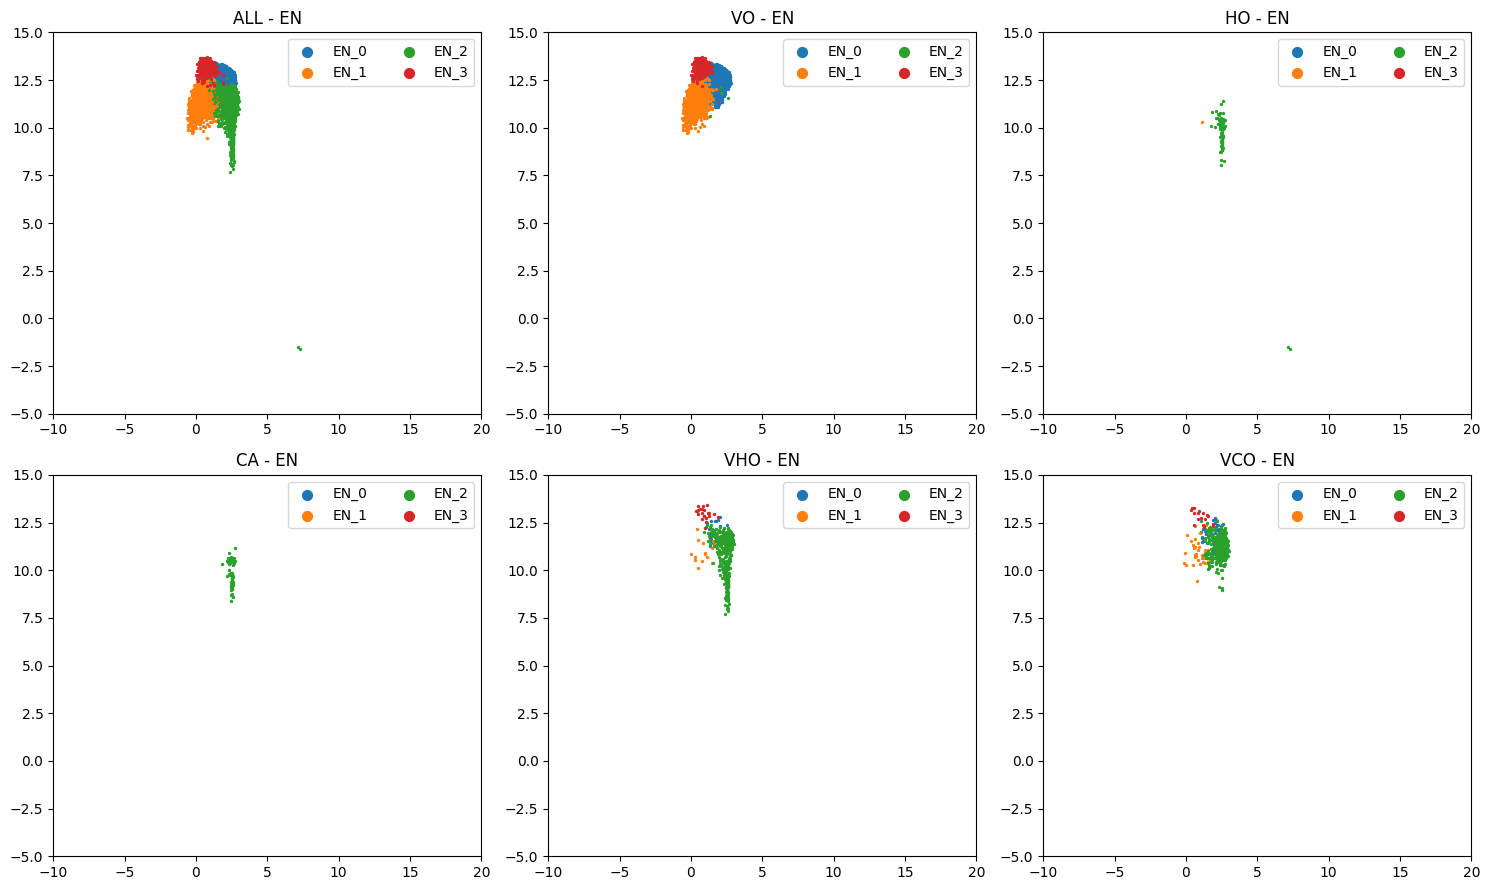

In [40]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for i in range(0, len(adata.obs['leiden'].unique())):
        adata_sub = adata_sample[adata_sample.obs['leiden'] == str(i)]
        ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=f"{ct}_{i}", s=2)
    
    ax.set_xlim([-10, 20])
    ax.set_ylim([-5, 15])
    ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/subclusters_{ct}.png')
plt.show()

In [41]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')
adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

### 2.4 don't subcluster other celltypes for now

In [42]:
cts = ['PR','SM','EP','CME']

for ct in cts:
    adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
    adata.obs['cell_type_subcluster'] = adata.obs['cell_type'].copy()
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

### 2.5 rearrange according to experiment

In [108]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/sample_recollect

In [51]:
cell_type_subcluster = []

for sample in ['ALL','VO','HO','CA','VHO','VCO']:
    for ct in ['CM','PR','FB','SM','EP','EN','CME']:
        
        adata_ct = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
        
        if sample == 'ALL':
            adata_ct_sample = adata_ct
            cell_type_subcluster = cell_type_subcluster + adata_ct.obs['cell_type_subcluster'].unique().to_list()
            cell_type_subcluster.sort()
        else:
            adata_ct_sample = adata_ct[adata_ct.obs['batch'] == sample]

        if ct == 'CM':
            adata_sample = adata_ct_sample
        else:
            adata_sample = ad.concat([adata_sample, adata_ct_sample], join='inner', axis=0)
            
    adata_sample.write_h5ad(f"{WORK_DIR}/adata/sample_recollect/{sample}.h5ad")

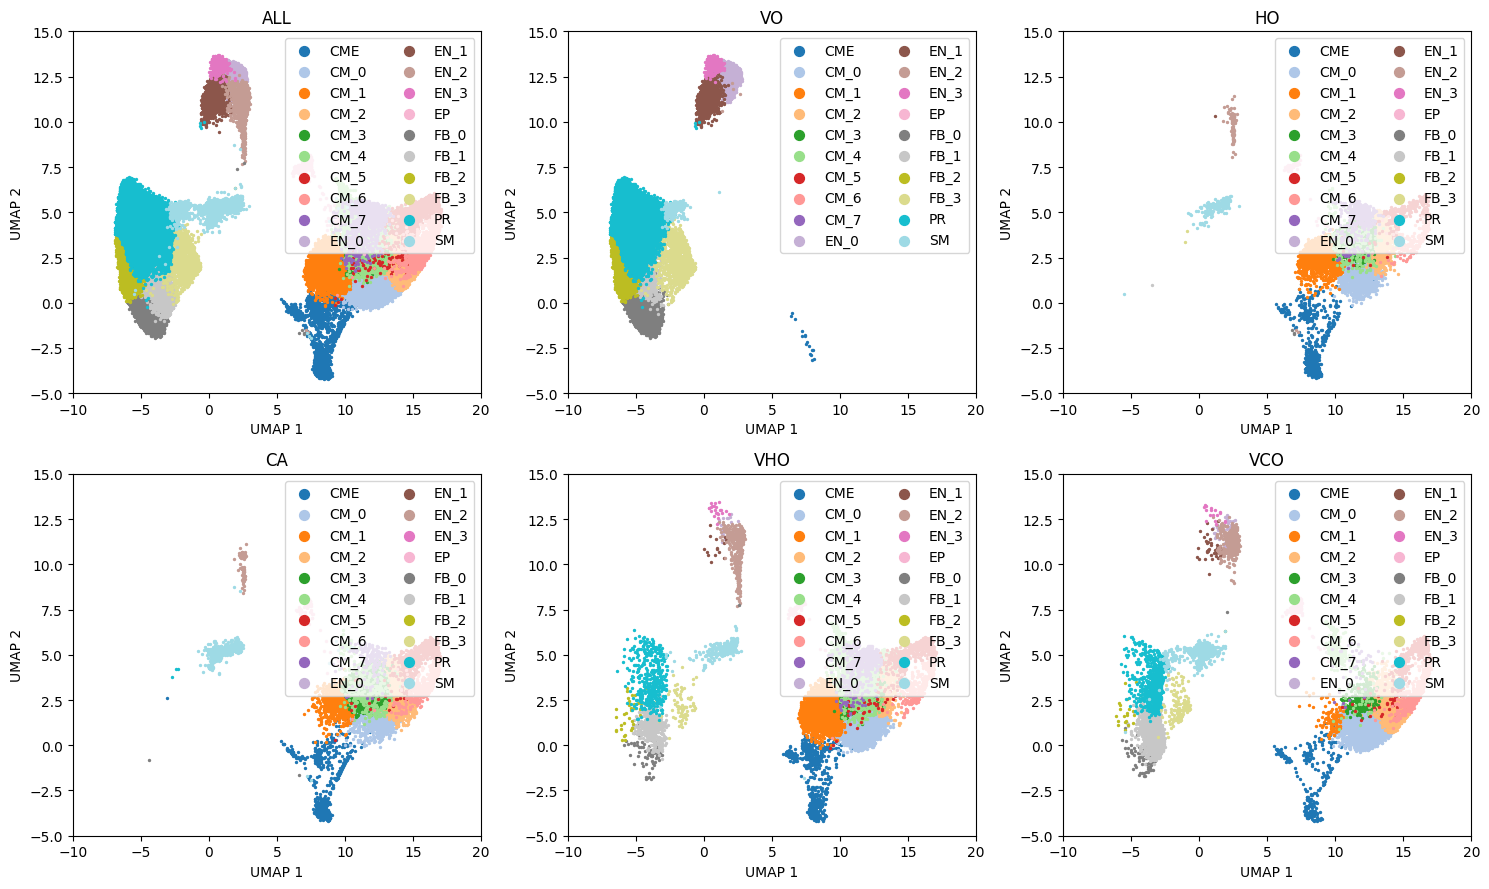

In [53]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors

batch_mapper = dict(zip(samples_old, samples))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/{sample}.h5ad')
    
    for j, cts in enumerate(cell_type_subcluster):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 1], 
            label=cts, 
            color=colors[j], s=2)
        
    axs[i].legend(loc='upper right', markerscale=5, ncol=2)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-10, 20])
    axs[i].set_ylim([-5, 15])
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/uamps/sample_recollect.png')
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

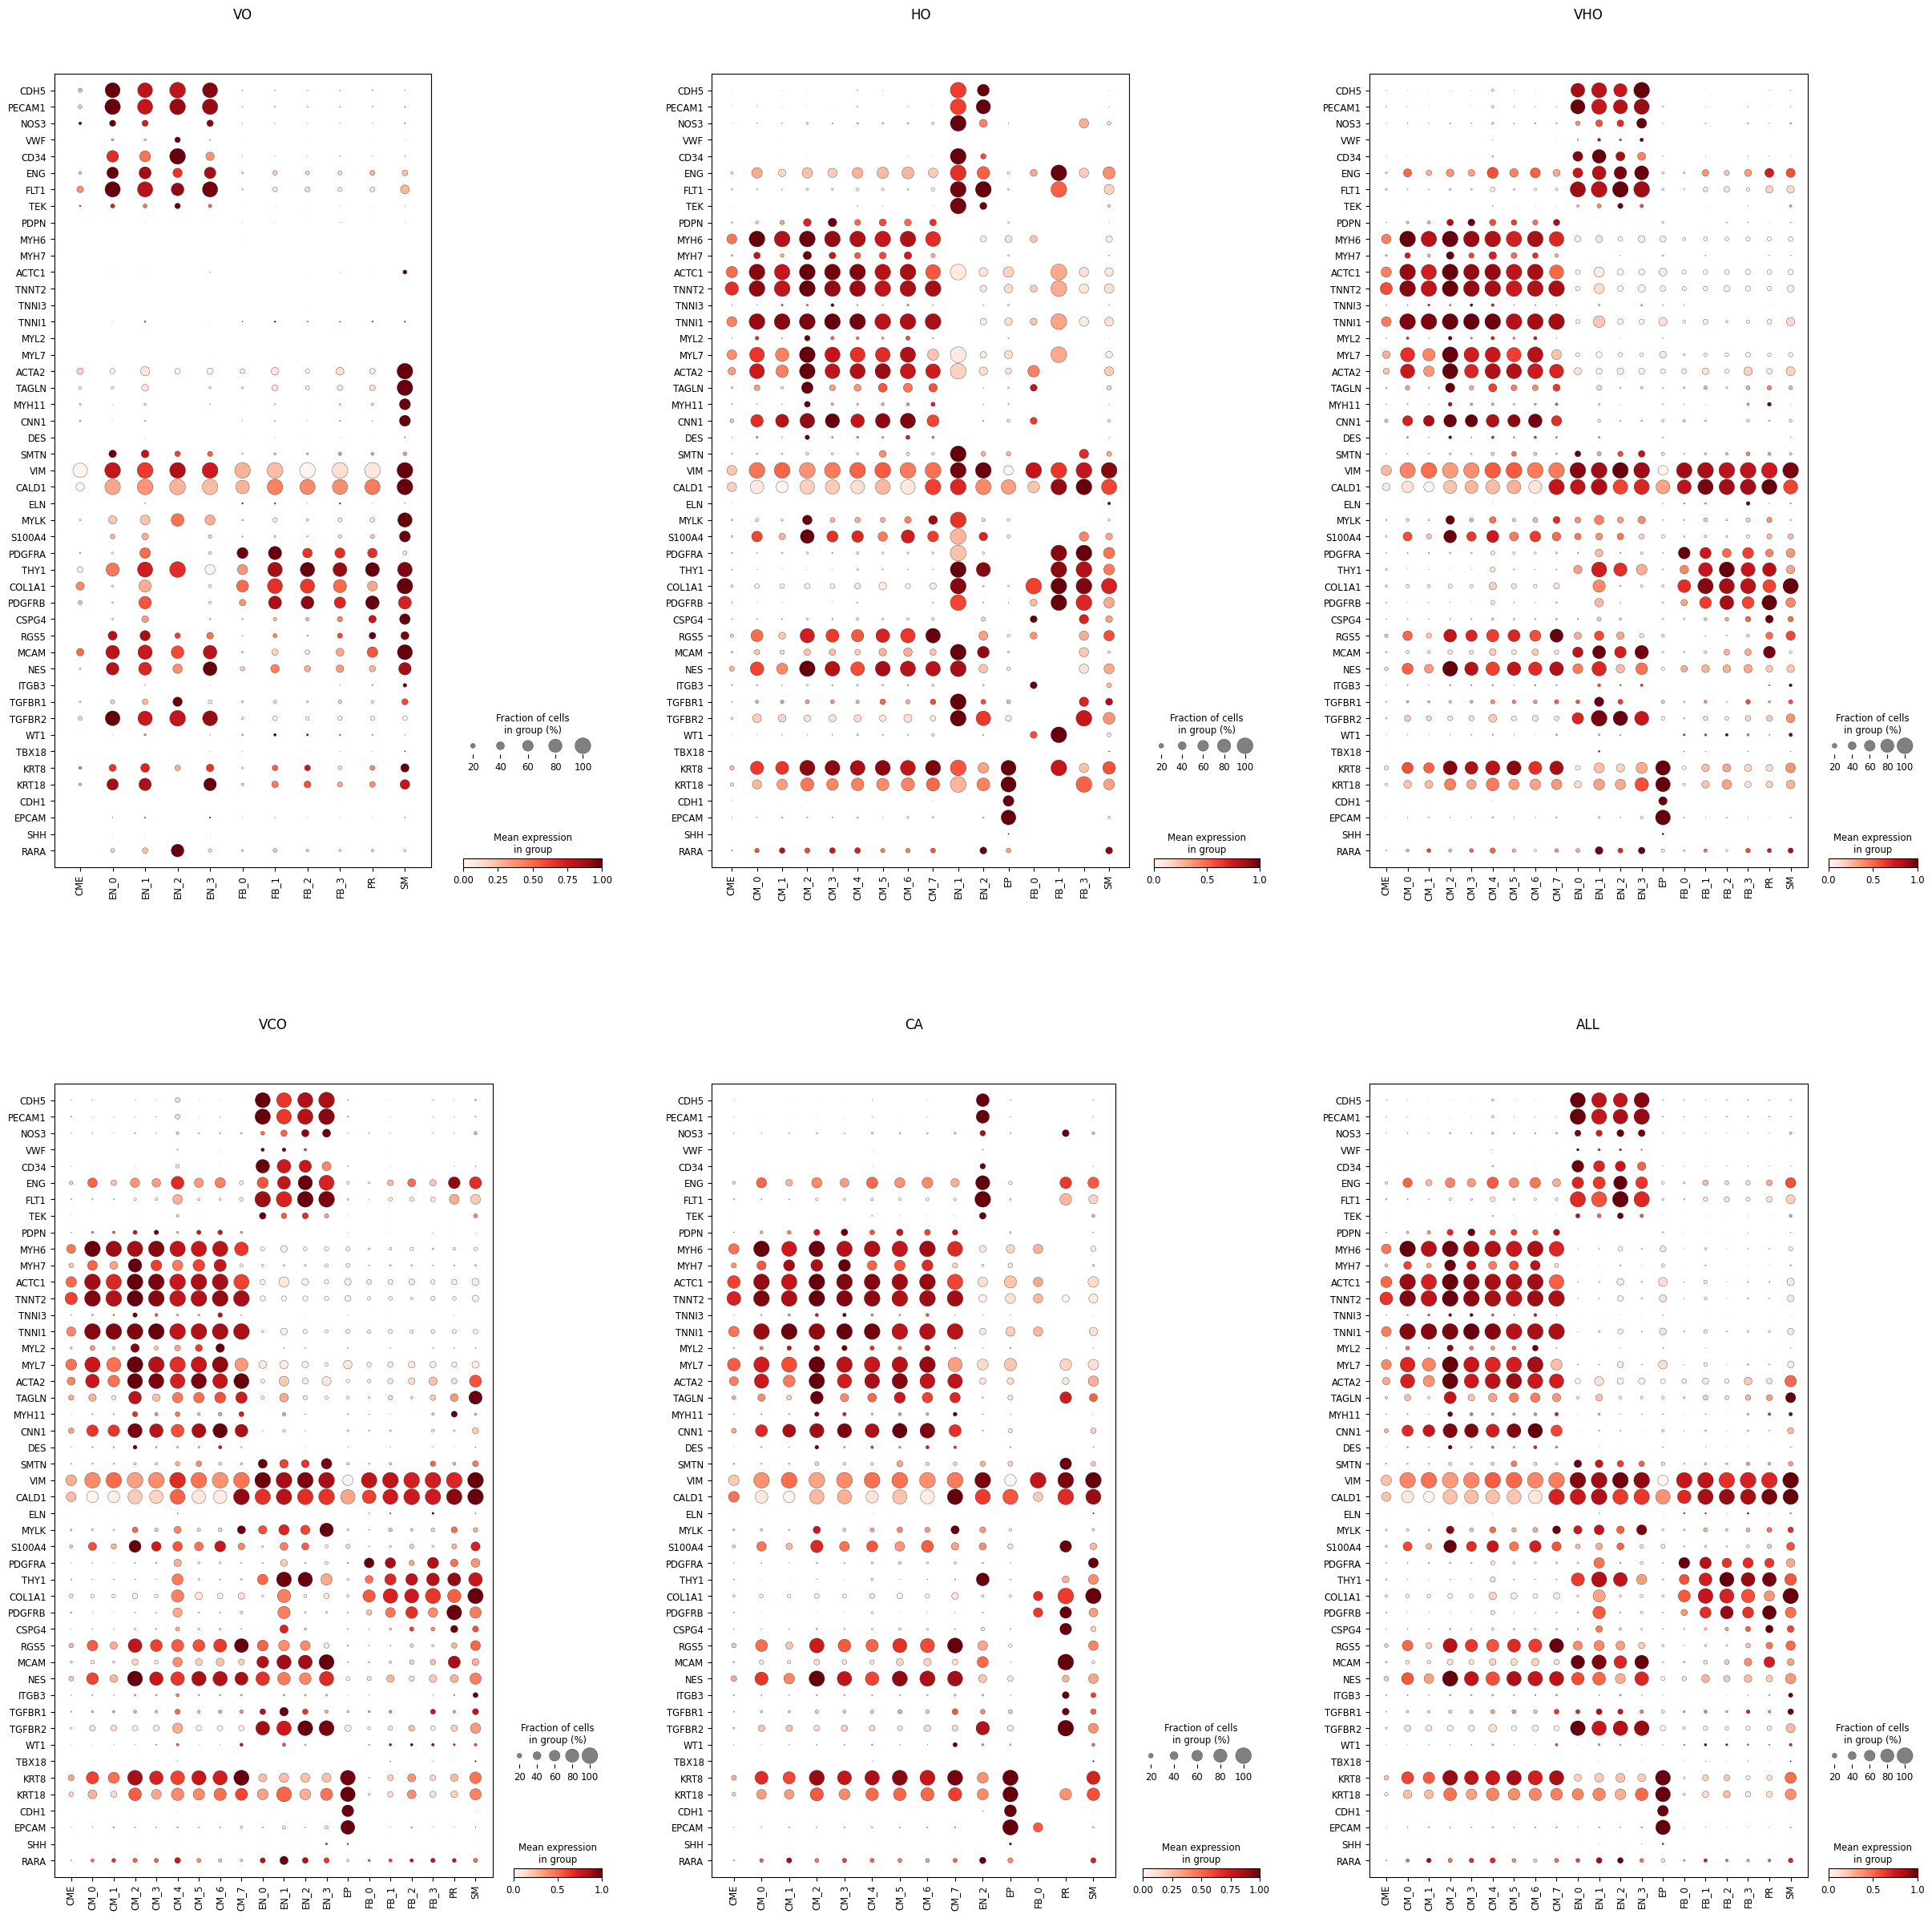

In [54]:
marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
               'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
               'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
               'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
               'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/sample_recollect/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/dotplot_celltype_subcluster.png')
plt.show()

## 3. DE between samples

In [42]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano

In [55]:
adata_BVO = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/VO.h5ad')
adata_HO = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/HO.h5ad')
adata_CM3O = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/CA.h5ad')
adata_BHO = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/VHO.h5ad')
adata_CM3B = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/VCO.h5ad')

adatas = {'HO': adata_HO, 'VO': adata_BVO, 'CA': adata_CM3O, 'VHO': adata_BHO, 'VCO': adata_CM3B}

In [61]:
def volcano_plot(adata1, adata2, celltype, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 1
    pvalue_thres = 5
    
    if np.any(adata1.var_names != adata2.var_names):
        raise ValueError('adata var names not unified')
    
    PSEUDOCOUNT=0.001
    data1 = adata1.X[adata1.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT
    data2 = adata2.X[adata2.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

In [62]:
def volcano_plot2(adata1, celltype_subcluster1, celltype_subcluster2, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 1
    pvalue_thres = 5
    
    PSEUDOCOUNT=0.001
    data1 = adata1.X[adata1.obs['cell_type_subcluster'] == celltype_subcluster1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs['cell_type_subcluster'] == celltype_subcluster2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

### 3.1 Cardiomyocyte

In [63]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/CM

In [64]:
celltype = 'CM'
adata_list = ['HO', 'CA', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


### 3.2 Endothelial cell

In [65]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/EN

In [66]:
celltype = 'EN'
adata_list = ['VO', 'HO', 'CA', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

### 3.3 Fibroblast

In [67]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/FB

In [68]:
celltype = 'FB'
adata_list = ['VO', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


### 3.4 Epithelial

In [69]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/EP

In [70]:
celltype = 'EP'
adata_list = ['HO', 'VHO', 'VCO', 'CA']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

### 3.5 Smooth muscle cell

In [71]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/SM

In [72]:
celltype = 'SM'
adata_list = ['VO', 'HO', 'VHO', 'VCO', 'CA']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

### 3.6 Pericytes

In [73]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/PR

In [74]:
celltype = 'PR'
adata_list = ['VO', 'VHO', 'VCO']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


### 3.7 Cardiomesoderm

In [75]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/CME

In [76]:
celltype = 'CME'
adata_list = ['HO', 'VHO', 'VCO', 'CA']

for i in range(0, len(adata_list)):
    for j in range(i+1, len(adata_list)):
        adata2 = adatas[adata_list[i]]
        adata1 = adatas[adata_list[j]]
        volcano_plot(adata1, 
                     adata2, 
                     celltype, 
                     f'{celltype} ({adata_list[i]} vs {adata_list[j]})', 
                     save=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.png', 
                     save_tsv=f'{WORK_DIR}/volcano/{celltype}/{celltype}.{adata_list[i]}.{adata_list[j]}.tsv')

/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/1982685702.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

## 4. DE between subclusters

In [21]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/CM_subcluster
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/FB_subcluster
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/volcano/EN_subcluster

In [79]:
ct = "EN"
sample = 'VCO'
CM_subclusters = [s for s in cell_type_subcluster if ct in s]

for i in range(0, len(CM_subclusters)):
    for j in range(i+1, len(CM_subclusters)):
        subc1 = CM_subclusters[i]
        subc2 = CM_subclusters[j]
        volcano_plot2(adatas[sample], 
                      subc1, 
                      subc2, 
                      f"{sample} ({subc1} vs {subc2})", 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

In [80]:
ct = "FB"
sample = 'VCO'
CM_subclusters = [s for s in cell_type_subcluster if ct in s]

for i in range(0, len(CM_subclusters)):
    for j in range(i+1, len(CM_subclusters)):
        subc1 = CM_subclusters[i]
        subc2 = CM_subclusters[j]
        volcano_plot2(adatas[sample], 
                      subc1, 
                      subc2, 
                      f"{sample} ({subc1} vs {subc2})", 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

In [84]:
ct = "CM"
sample = 'VCO'
CM_subclusters = [s for s in cell_type_subcluster if f"{ct}_" in s]

for i in range(0, len(CM_subclusters)):
    for j in range(i+1, len(CM_subclusters)):
        subc1 = CM_subclusters[i]
        subc2 = CM_subclusters[j]
        volcano_plot2(adatas[sample], 
                      subc1, 
                      subc2, 
                      f"{sample} ({subc1} vs {subc2})", 
                      save=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}_subcluster/{sample}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_1044410/2160139853.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats

## 5. Velocity

In [1]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity

In [1]:
%%bash
qsub /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity/scVelo_job.sh

requested Hard Resources
  memory (s_vmem): 128G = The job requires 128GB of memory per slot.
  slots (def_slot): 1 = The job requires 100% of CPU.
  total memory: 128G = The job requires 128GB of memory.
  Resource list: lmem
Your job 109886053 ("scVelo_job.sh") has been submitted


In [ ]:
# activate scVelo env for this

import scvelo as scv
import scanpy as sc
import matplotlib.pyplot as plt

In [ ]:
loom_file_names = ['BVO', 'HO', 'CM3O', 'BHO', 'CM3B']
adata_file_names = ['VO', 'HO', 'CA', 'VHO', 'VCO']

for i in range(0, 5):

    loom_file = f'/home/herbert/PyProjects/cocultured_organ/data/240603/SC160__{loom_file_names[i]}-JW-052224/SC160__{loom_file_names[i]}-JW-052224.loom'
    ldata = sc.read(loom_file, cache=True)
    adata = sc.read_h5ad(f'/home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/sample_recollect/{adata_file_names[i]}.h5ad')
    adata = scv.utils.merge(adata, ldata)

    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
    scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
    scv.tl.velocity(adata)
    scv.tl.velocity_graph(adata)
    scv.pl.velocity_embedding_stream(adata, basis='umap', color='cell_type_subcluster', save=f"{WORK_DIR}/velocity/{adata_file_names[i]}.png")

## 6. GO enrichment

In [9]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/GO_enrich

In [8]:
%%bash
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/GO_enrich

In [14]:
import scanpy as sc
import gseapy as gp
import pandas as pd

sample = "VCO"

adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/{sample}.h5ad")

# 1) Differential expression
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='wilcoxon')

# 2) Extract results
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

top_genes_dict = {}
n_top_genes = 100

for group in groups:
    gene_names = result['names'][group][:n_top_genes].tolist()
    pvals_adj = result['pvals_adj'][group][:n_top_genes].tolist()
    df = pd.DataFrame({'gene': gene_names, 'pval_adj': pvals_adj})
    top_genes_dict[group] = df

# 3) GO Enrichment with Enrichr library in GSEApy
library_name = 'GO_Biological_Process_2021'
enrichment_results = {}

for cell_type, df_genes in top_genes_dict.items():
    if cell_type == "CME":
        continue
    
    gene_list = df_genes['gene'].tolist()
    
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=[library_name],
        organism='Human',  
        outdir=f"{WORK_DIR}/GO_enrich/{cell_type}"
    )
    
    enrichment_results[cell_type] = enr.results

# 4) Inspect results
for cell_type, df_res in enrichment_results.items():
    print(f"Top terms for {cell_type}")
    print(df_res[['Term','P-value','Adjusted P-value','Genes']].head(10))
    print("-----")

Top terms for CM
                                                Term       P-value  \
0                    muscle contraction (GO:0006936)  2.449810e-26   
1                     heart contraction (GO:0060047)  7.456798e-23   
2            cardiac muscle contraction (GO:0060048)  6.173218e-20   
3         actin-myosin filament sliding (GO:0033275)  2.998924e-19   
4               muscle filament sliding (GO:0030049)  2.998924e-19   
5           striated muscle contraction (GO:0006941)  5.088311e-19   
6   cardiac muscle tissue morphogenesis (GO:0055008)  3.274950e-18   
7  ventricular cardiac muscle tissue morphogenesi...  6.390400e-14   
8       cardiac muscle cell development (GO:0055013)  2.020757e-13   
9      regulation of muscle contraction (GO:0006937)  8.401197e-13   

   Adjusted P-value                                              Genes  
0      2.437561e-23  MYBPC3;TMOD1;MYOM1;SMPX;ACTN2;TNNC1;TPM1;SLC8A...  
1      3.709757e-20  MYBPC3;RYR2;TNNC1;TPM1;ATP1B1;SLC8A1;TTN;TRDN